In [23]:
import importlib.util
import subprocess
import sys

required = ["pandas", "numpy", "sklearn"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


In [24]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve().parent))

import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from src.evaluate import load_data, cv_rmsle
from src.features import build_features

train, test = load_data()

X = build_features(train)
y = train["count"]

print("Training data:", X.shape)
print("Target:", y.shape)

Training data: (10886, 67)
Target: (10886,)


In [25]:
from sklearn.model_selection import ParameterGrid

dt_params = {
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_results = []

for params in ParameterGrid(dt_params):

    model = DecisionTreeRegressor(
        random_state=42,
        **params
    )

    score = cv_rmsle(
        model,
        X,
        y,
        log_target=True
    )

    dt_results.append({
        **params,
        "cv_rmsle": score
    })

    print(params, "->", round(score, 4))

dt_results_df = pd.DataFrame(dt_results)

dt_results_df = dt_results_df.sort_values(
    "cv_rmsle"
).reset_index(drop=True)

dt_results_df.head(10)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2} -> 0.5684
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5} -> 0.5674
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10} -> 0.564
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2} -> 0.567
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5} -> 0.5666
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10} -> 0.5637
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2} -> 0.5615
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5} -> 0.5615
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10} -> 0.5615
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2} -> 0.4576
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5} -> 0.4516
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10} -> 0.4417
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2} -> 0.4496
{'max_depth': 15, 'min_

,max_depth,min_samples_leaf,min_samples_split,cv_rmsle
0,NaN,5,5,0.410521
1,NaN,5,10,0.410521
2,NaN,5,2,0.410521
3,NaN,2,10,0.414043
4,20.0,5,10,0.414403
5,20.0,5,2,0.414403
6,20.0,5,5,0.414403
7,20.0,2,10,0.415530
8,NaN,1,10,0.416884
9,20.0,1,10,0.421705


In [26]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 1.0]
}

rf_results = []

for params in ParameterGrid(rf_params):

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params
    )

    score = cv_rmsle(
        model,
        X,
        y,
        log_target=True
    )

    rf_results.append({
        **params,
        "cv_rmsle": score
    })

    print(params, "->", round(score, 4))

rf_results_df = pd.DataFrame(rf_results)

rf_results_df = rf_results_df.sort_values(
    "cv_rmsle"
).reset_index(drop=True)

rf_results_df.head(10)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} -> 0.4028
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} -> 0.4011
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100} -> 0.4107
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200} -> 0.4109
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100} -> 0.4333
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200} -> 0.4333
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100} -> 0.434
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200} -> 0.4325
{'max_depth': None, 'max_

,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,cv_rmsle
0,NaN,1.0,1,2,200,0.321353
1,NaN,1.0,1,5,200,0.321450
2,NaN,1.0,1,5,100,0.322307
3,NaN,1.0,1,2,100,0.322612
4,25.0,1.0,1,2,200,0.322781
5,25.0,1.0,1,5,200,0.322960
6,25.0,1.0,1,5,100,0.323708
7,25.0,1.0,1,2,100,0.323906
8,NaN,1.0,2,2,200,0.325704
9,NaN,1.0,2,5,200,0.325707


In [ ]:
if "rf_results_df" in globals():
    print("Best Random Forest parameters:")
    print(rf_results_df.iloc[0])
else:
    print("Run the Random Forest tuning cell first.")


Best Random Forest parameters:
max_depth                 NaN
max_features              1.0
min_samples_leaf            1
min_samples_split           2
n_estimators              200
cv_rmsle             0.321353
Name: 0, dtype: object


In [16]:
gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_results = []

for params in ParameterGrid(gb_params):

    model = GradientBoostingRegressor(
        random_state=42,
        **params
    )

    score = cv_rmsle(
        model,
        X,
        y,
        log_target=True
    )

    gb_results.append({
        **params,
        "cv_rmsle": score
    })

    print(params, "->", round(score, 4))

gb_results_df = pd.DataFrame(gb_results)

gb_results_df = gb_results_df.sort_values(
    "cv_rmsle"
).reset_index(drop=True)

gb_results_df.head(10)

{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} -> 0.8264
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} -> 0.6322
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300} -> 0.538
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100} -> 0.8264
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200} -> 0.6322
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300} -> 0.538
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100} -> 0.8264
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200} -> 0.6322
{'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf'

,learning_rate,max_depth,min_samples_leaf,min_samples_split,n_estimators,cv_rmsle
0,0.1,4,2,5,300,0.306316
1,0.1,4,1,5,300,0.306630
2,0.1,4,1,2,300,0.307067
3,0.1,4,2,2,300,0.307361
4,0.1,4,2,5,200,0.320859
5,0.1,4,1,2,200,0.320917
6,0.1,4,2,2,200,0.321415
7,0.1,4,1,5,200,0.321591
8,0.1,3,1,5,300,0.324004
9,0.1,3,1,2,300,0.324353


In [17]:
if "gb_results_df" in globals():
    print("Best Gradient Boosting parameters:")
    print(gb_results_df.iloc[0])
else:
    print("Run the Gradient Boosting tuning cell first.")


Best Gradient Boosting parameters:
learning_rate          0.100000
max_depth              4.000000
min_samples_leaf       2.000000
min_samples_split      5.000000
n_estimators         300.000000
cv_rmsle               0.306316
Name: 0, dtype: float64


In [22]:
required_vars = ["dt_results_df", "rf_results_df", "gb_results_df"]
if all(var in globals() for var in required_vars):
    from pathlib import Path

    Path("../results").mkdir(exist_ok=True)

    dt_results_df.to_csv("../results/decision_tree_tuning.csv", index=False)
    rf_results_df.to_csv("../results/random_forest_tuning.csv", index=False)
    gb_results_df.to_csv("../results/gradient_boosting_tuning.csv", index=False)

    print("Tuning results saved successfully.")
else:
    print("Run the tree, random forest, and gradient boosting tuning cells first.")


Tuning results saved successfully.


In [ ]:
if "dt_results_df" in globals():
    print("Best Decision Tree parameters:")
    print(dt_results_df.iloc[0])
else:
    print("Run the Decision Tree tuning cell first.")


Best Decision Tree parameters:
max_depth                 NaN
min_samples_leaf     5.000000
min_samples_split    5.000000
cv_rmsle             0.410521
Name: 0, dtype: float64


In [34]:
if "X" in globals() and "y" in globals():
    from sklearn.ensemble import RandomForestRegressor
    import pandas as pd
    import matplotlib.pyplot as plt

    # Train tuned Random Forest on the complete training set
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X, y)

    # Extract feature importance
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    feature_importance.head(20)
else:
    print("Run the data-loading cell first so X and y exist.")


Matplotlib is building the font cache; this may take a moment.


In [31]:
import sys
print(sys.executable)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe


In [32]:
import sys
!{sys.executable} -m pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 407.1 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/132.6 kB ? eta -:--:--
     ------------------ -------------------- 61.4/132.6 kB 3.2 MB/s eta 0:00:01
     -------------------------------------- 132.6/132.6 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    --------------------------------------- 0.2/9.3 MB 5.9 MB/s eta 0:00:02
   - -------------------------------------- 0.3/9.3 MB 4.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/9.3 MB 4.6 MB/s eta 0:00:02
   --- ---------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import matplotlib
print(matplotlib.__version__)

3.11.2


In [35]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,feature,importance
0,peak_weekday,0.267743
1,peak_weekend,0.164025
2,year,0.097288
3,atemp,0.084686
4,temp,0.055768
5,humidity,0.055262
6,hour_9,0.025310
7,atemp_bin_gt30,0.021193
8,hour_16,0.017258
9,hour_20,0.015641


In [36]:
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

feature_importance.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


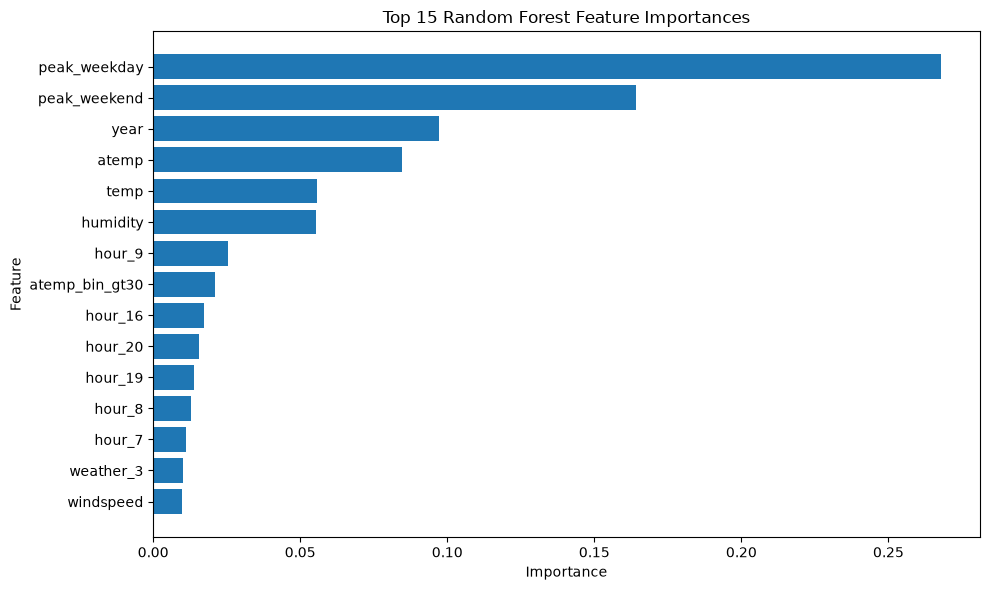

In [37]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [39]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

# Tuned Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train on log-transformed target
gb_model.fit(X, np.log1p(y))

# Predict and convert back to count scale
log_predictions = gb_model.predict(X)
predictions = np.expm1(log_predictions)

# Create error-analysis dataframe
error_analysis = train.copy()

# Derive hour from datetime
error_analysis["hour"] = error_analysis["datetime"].dt.hour

# Predictions
error_analysis["prediction"] = predictions

# Absolute error
error_analysis["absolute_error"] = (
    error_analysis["count"] - error_analysis["prediction"]
).abs()

# Show relevant columns
error_analysis = error_analysis[
    [
        "datetime",
        "hour",
        "workingday",
        "weather",
        "temp",
        "humidity",
        "windspeed",
        "count",
        "prediction",
        "absolute_error"
    ]
]

error_analysis.head()

,datetime,hour,workingday,weather,temp,humidity,windspeed,count,prediction,absolute_error
0,2011-01-01 00:00:00,0,0,1,9.84,81,0.0,16,22.101163,6.101163
1,2011-01-01 01:00:00,1,0,1,9.02,80,0.0,40,17.545831,22.454169
2,2011-01-01 02:00:00,2,0,1,9.02,80,0.0,32,13.437966,18.562034
3,2011-01-01 03:00:00,3,0,1,9.84,75,0.0,13,8.471093,4.528907
4,2011-01-01 04:00:00,4,0,1,9.84,75,0.0,1,2.236018,1.236018


In [40]:
hour_error = (
    error_analysis
    .groupby("hour")["absolute_error"]
    .mean()
    .reset_index()
    .sort_values("absolute_error", ascending=False)
)

hour_error

,hour,absolute_error
18,18,55.913176
17,17,51.612169
8,8,47.283298
19,19,43.021862
16,16,33.258285
9,9,31.768420
20,20,31.313790
13,13,29.154734
14,14,29.136442
15,15,28.741546


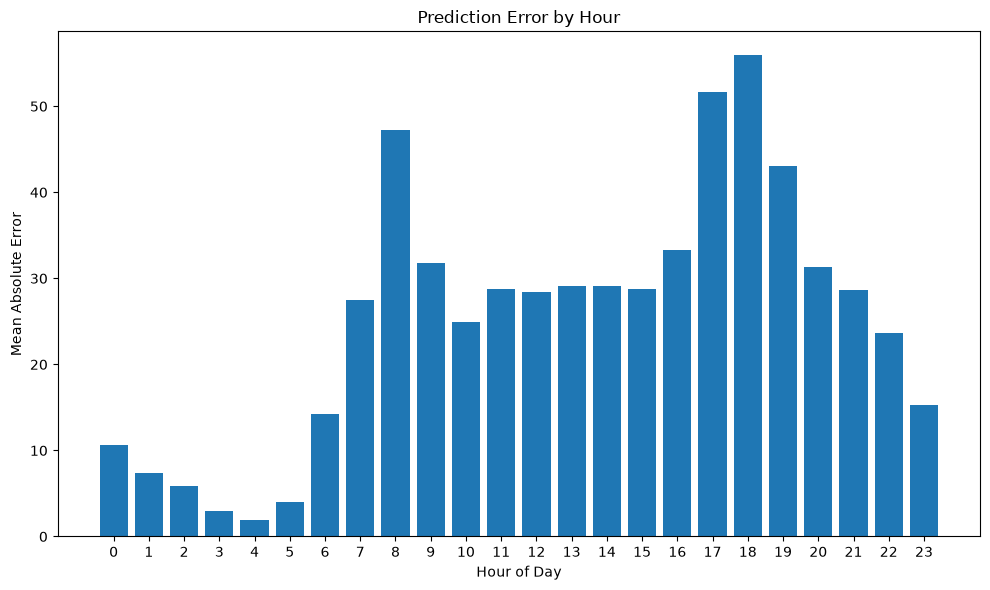

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    hour_error["hour"],
    hour_error["absolute_error"]
)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Hour")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [42]:
workingday_error = (
    error_analysis
    .groupby("workingday")["absolute_error"]
    .mean()
    .reset_index()
)

workingday_error["day_type"] = workingday_error["workingday"].map({
    0: "Non-working day",
    1: "Working day"
})

workingday_error

,workingday,absolute_error,day_type
0,0,27.505748,Non-working day
1,1,24.299911,Working day


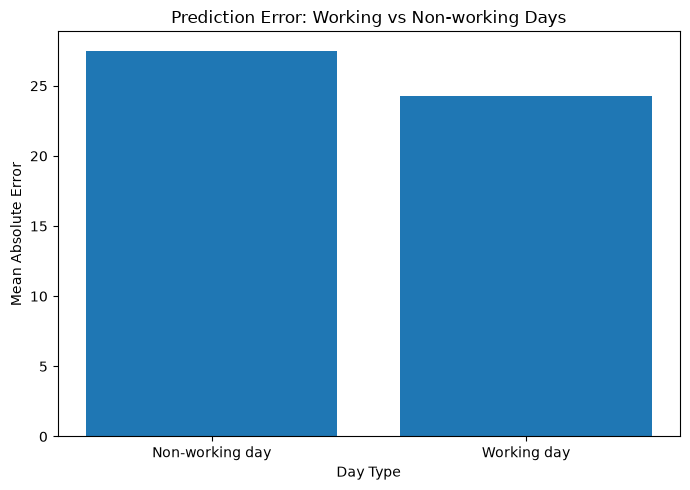

In [43]:
plt.figure(figsize=(7, 5))

plt.bar(
    workingday_error["day_type"],
    workingday_error["absolute_error"]
)

plt.xlabel("Day Type")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error: Working vs Non-working Days")

plt.tight_layout()
plt.show()

In [44]:
weather_error = (
    error_analysis
    .groupby("weather")["absolute_error"]
    .mean()
    .reset_index()
)

weather_error

,weather,absolute_error
0,1,24.455947
1,2,24.965809
2,3,33.641549
3,4,127.541704


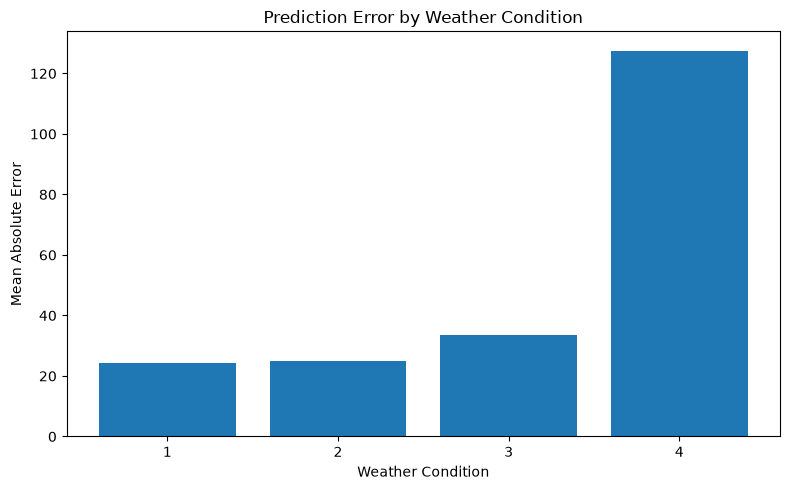

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_error["weather"].astype(str),
    weather_error["absolute_error"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Weather Condition")

plt.tight_layout()
plt.show()

In [46]:
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

hour_error.to_csv(
    "../results/error_by_hour.csv",
    index=False
)

workingday_error.to_csv(
    "../results/error_by_workingday.csv",
    index=False
)

weather_error.to_csv(
    "../results/error_by_weather.csv",
    index=False
)

print("Error analysis results saved successfully.")

Error analysis results saved successfully.


In [47]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Stacking Ensemble"
    ],
    "Baseline RMSLE": [
        0.4541,
        0.3214,
        0.4182,
        None
    ],
    "Tuned/Final RMSLE": [
        0.4105,
        0.3214,
        0.3063,
        0.3110
    ]
})

final_results["Improvement"] = (
    final_results["Baseline RMSLE"]
    - final_results["Tuned/Final RMSLE"]
)

final_results

,Model,Baseline RMSLE,Tuned/Final RMSLE,Improvement
0,Decision Tree,0.4541,0.4105,0.0436
1,Random Forest,0.3214,0.3214,0.0000
2,Gradient Boosting,0.4182,0.3063,0.1119
3,Stacking Ensemble,NaN,0.3110,NaN


In [48]:
final_results.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


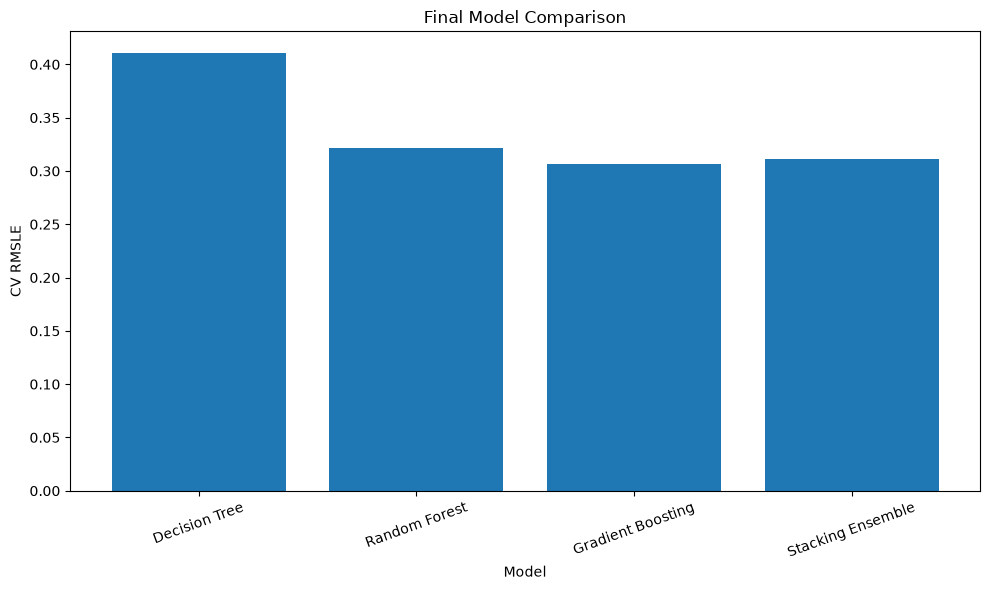

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Tuned/Final RMSLE"]
)

plt.ylabel("CV RMSLE")
plt.xlabel("Model")
plt.title("Final Model Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()